In [50]:
import numpy as np
import matplotlib.pyplot as plt

## parameters

The code is flexible , you can add more parameters like w4 , w5 , ...

In [51]:
number_of_data = 1000
number_of_epochs = 10000
learning_rate = 0.01
w1 = 123
w2 = -78
w3 = 7
b0 = 1000

# 1. Data

Data generated randomly, The best result depends on the numbers of data ,learning rate , cost function,normalization the data , and etc<br>
I skiped this step becuase, for now the main idea of making a linear regression with gradient descent is more important.

In [52]:
np.random.seed(42)
x1 = abs(np.random.random(number_of_data)) * 2.3
x2 = abs(np.random.random(number_of_data)) * np.exp(1) + 1.2
x3 = abs(np.random.random(number_of_data)) * np.exp(1)*0.7 + 1.5
x = [x1 , x2 , x3]
y = w1 * x1 + w2 * x2 + w3 * x3 + b0 + np.random.randn(number_of_data) 

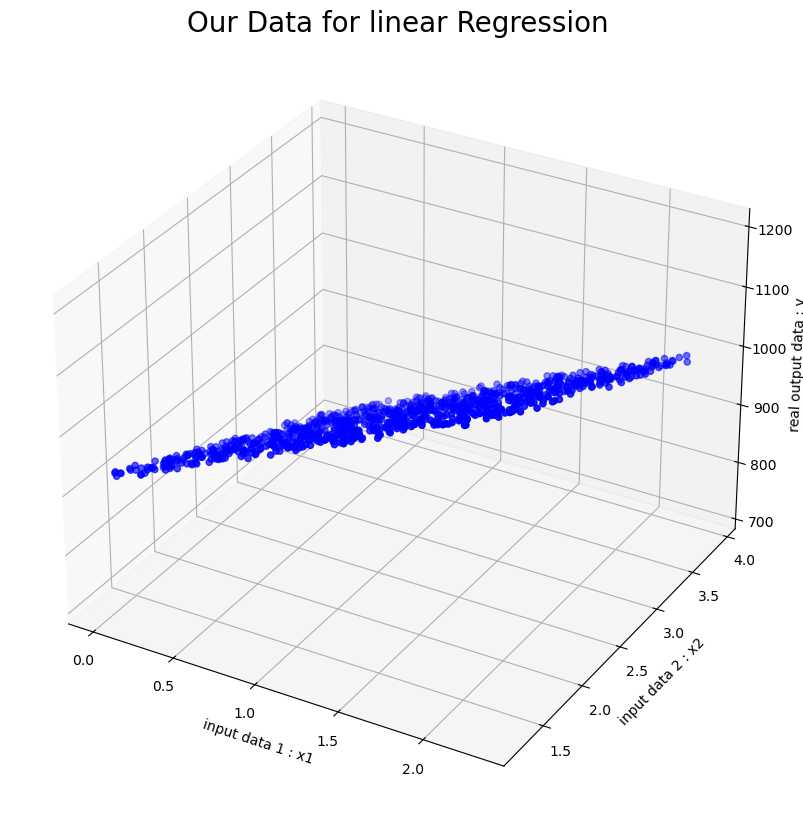

In [53]:
fig = plt.figure(figsize= (10 , 15))
ax = fig.add_subplot(projection='3d')
ax.scatter3D(x[0] , x[1] , y , color = "b")
ax.set_xlabel("input data 1 : x1")
ax.set_ylabel("input data 2 : x2")
ax.set_zlabel("real output data : y")
ax.set_title("Our Data for linear Regression" , fontsize = 20  ) 
plt.show()


# 2. functions

In [54]:
def cost_function(y , yhat):
    return 1 / len(y) * np.sum((y - yhat)**2)

In [55]:
def linear_regression (x , y , w , b):
    sumx = np.zeros(len(x[0]))
    for n in range(len(x)):
        sumx = sumx + w[n] * x[n]
    return sumx + b #yhat

In [ ]:
def linear_reg_mse(x , y , epochs, alpha):
    delta = 0.00000001
    i = len(x)
    w = np.ones((epochs + 1 , i))
    wdelta = np.zeros(i)
    b = np.zeros(epochs + 1)
    cost = np.zeros(epochs + 1)

    #these lines below are the gradient descent implementation
    for n in range(epochs):
        cost[n] = cost_function(y , linear_regression (x , y , w[n] , b[n]))
        for m in range(i):
            wdelta[m] = delta 
            sse1 = cost_function(linear_regression (x , y , w[n]  , b[n]) , y)
            sse2 = cost_function(linear_regression (x , y , w[n] + wdelta , b[n]) , y)
            w[n + 1 , m] = w[n , m] - alpha * (sse2 - sse1 ) / delta
            wdelta = np.zeros(i)
        sse3 = cost_function(linear_regression (x , y , w[n] , b[n] ) , y)
        sse4 = cost_function(linear_regression (x , y , w[n] , b[n] + delta) , y)
        b[n + 1] = b[n] - alpha * (sse4 - sse3 ) / delta

    return linear_regression (x , y , w[epochs ] , b[epochs ]) , w , b , cost

# 3. Complie and results

In [57]:
yhat , w , b , cost = linear_reg_mse(x , y , epochs=number_of_epochs , alpha = learning_rate)

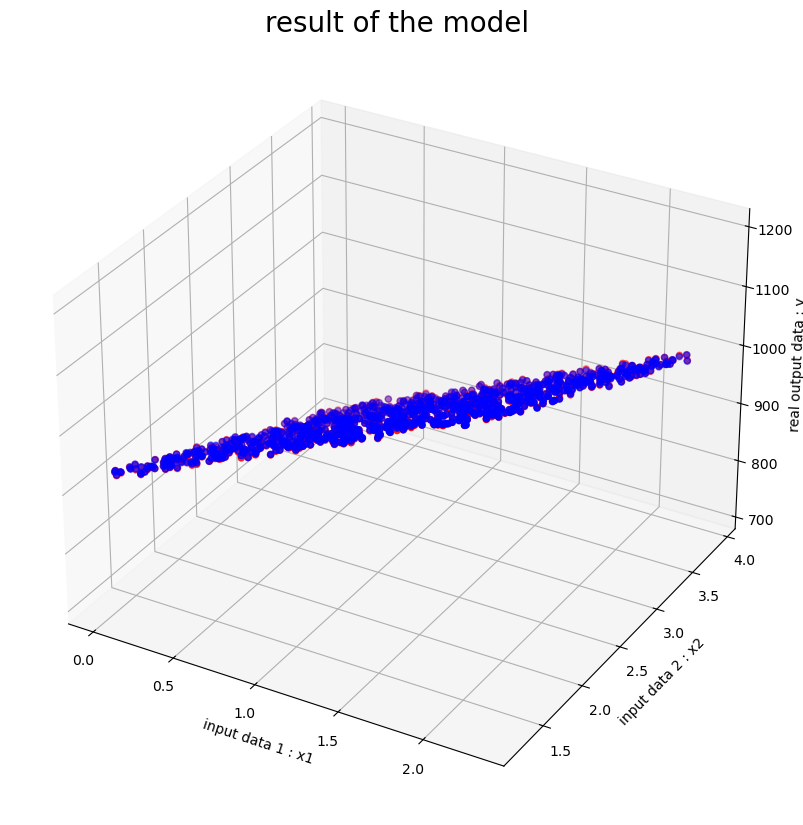

In [58]:
fig = plt.figure(figsize= (10 , 15))
ax = fig.add_subplot(projection='3d')
ax.scatter3D(x[0] , x[1] , y , color = "b")
ax.scatter3D(x[0] , x[1] , yhat , color = "r")
ax.set_xlabel("input data 1 : x1")
ax.set_ylabel("input data 2 : x2")
ax.set_zlabel("real output data : y")
ax.set_title("result of the model" , fontsize = 20  ) 
plt.show()

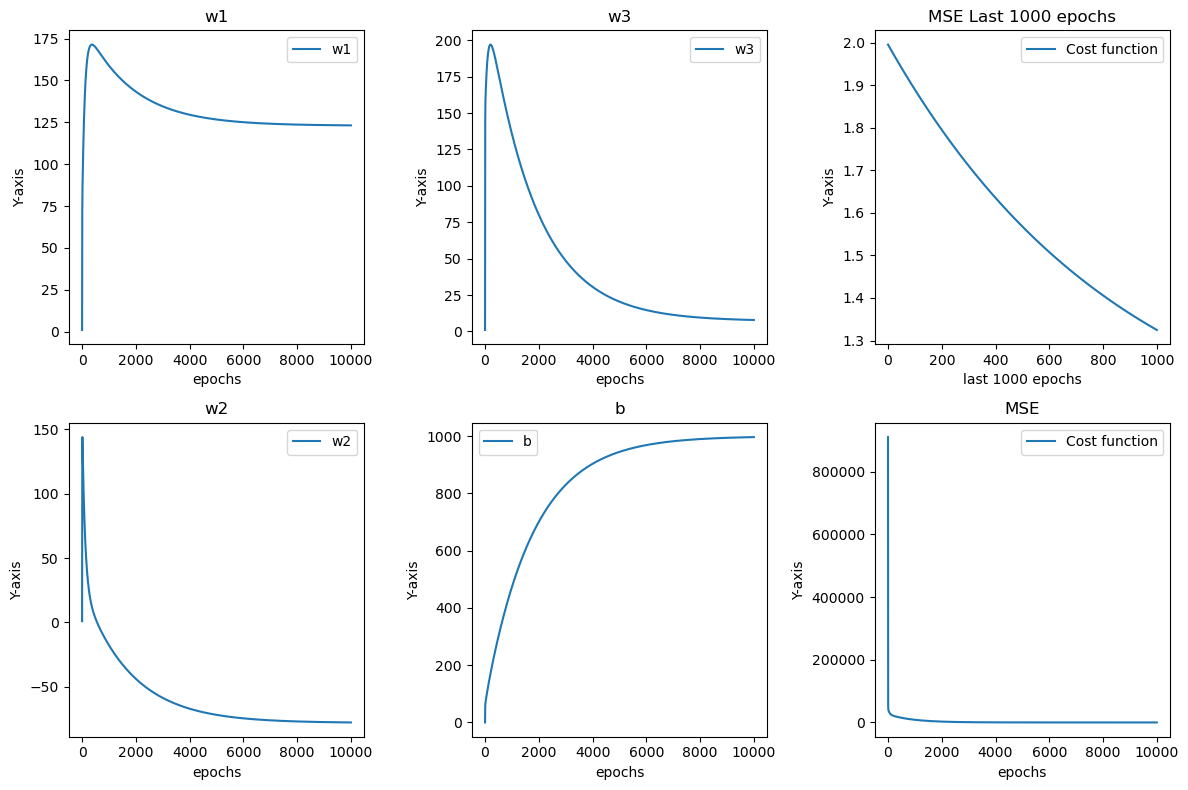

In [59]:
# Create the figure and subplots
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Plot the data on the subplots
axes[0, 0].plot(w[: , 0], label='w1')
axes[0, 0].set_title('w1')
axes[0, 0].set_xlabel('epochs')
axes[0, 0].set_ylabel('Y-axis')
axes[0, 0].legend()

axes[1, 0].plot( w[: , 1], label='w2')
axes[1, 0].set_title('w2')
axes[1, 0].set_xlabel('epochs')
axes[1, 0].set_ylabel('Y-axis')
axes[1, 0].legend()

axes[0, 1].plot( w[: , 2], label='w3')
axes[0, 1].set_title('w3')
axes[0, 1].set_xlabel('epochs')
axes[0, 1].set_ylabel('Y-axis')
axes[0, 1].legend()

axes[1, 1].plot( b, label='b')
axes[1, 1].set_title('b')
axes[1, 1].set_xlabel('epochs')
axes[1, 1].set_ylabel('Y-axis')
axes[1, 1].legend()

axes[0, 2].plot(cost[number_of_epochs -1000 : -1], label='Cost function')
axes[0, 2].set_title('MSE Last 1000 epochs')
axes[0, 2].set_xlabel('last 1000 epochs')
axes[0, 2].set_ylabel('Y-axis')
axes[0, 2].legend()

axes[1, 2].plot(cost, label='Cost function')
axes[1, 2].set_title('MSE')
axes[1, 2].set_xlabel('epochs')
axes[1, 2].set_ylabel('Y-axis')
axes[1, 2].legend()

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Show the plot
plt.show()

In [60]:
print(f"The result for learning rate: {learning_rate} and epochs number: {number_of_epochs}")
print(f"w were: {w1} , {w2} , {w3} and our model forecast {w[number_of_epochs]}")
print(f"b was: {b0} and our model forecast {b[number_of_epochs]}")
print(f"The last cost function number was = {cost[number_of_epochs-1]}")

The result for learning rate: 0.01 and epochs number: 10000
w were: 123 , -78 , 7 and our model forecast [123.16736746 -77.6682579    7.84044166]
b was: 1000 and our model forecast 996.8025944546711
The last cost function number was = 1.3248158494915956
